### Notebook Overview

This notebook applies **SHAP** and **LIME** explainability techniques to the best-performing model from the project: the Extra Trees Regressor from Phase 3 (hybrid approach).

**Goal:** Understand *which features* drive car price predictions and *by how much*, giving us business-level insight into what makes a car expensive or cheap in the model's eyes.

**Sections:**
1. Setup and model training
2. SHAP global explanations (which features matter overall)
3. SHAP local explanations (why a specific car got its price)
4. LIME local explanations (alternative perspective on individual predictions)
5. SHAP vs LIME comparison
6. Business interpretation

### 1 - Setup

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualisations
import matplotlib.pyplot as plt
import shap

# Model building
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import lime.lime_tabular

In [2]:
# Data
X_train = pd.read_csv("../data/x-train.csv")
X_test = pd.read_csv("../data/x-test.csv")
y_train = pd.read_csv("../data/y-train.csv").squeeze()
y_test = pd.read_csv("../data/y-test.csv").squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {list(X_train.columns)}")

Train: (164, 35), Test: (41, 35)
Features: ['symboling', 'fueltype', 'aspiration', 'doornumber', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'avg_mpg', 'hp_per_weight', 'brand_tier', 'carbody_hardtop', 'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'drivewheel_fwd', 'drivewheel_rwd', 'enginetype_dohcv', 'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv', 'enginetype_rotor', 'fuelsystem_2bbl', 'fuelsystem_4bbl', 'fuelsystem_idi', 'fuelsystem_mfi', 'fuelsystem_mpfi', 'fuelsystem_spdi', 'fuelsystem_spfi']


We train the Extra Trees model fresh here rather than loading the PyCaret pickle. Since Phase 3 used `preprocess=False`, PyCaret trained a standard `ExtraTreesRegressor` on this exact data. Training it directly avoids needing PyCaret as a dependency for this notebook.

In [3]:
model = ExtraTreesRegressor(random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Extra Trees - MAE: ${mae:,.0f}, R2: {r2:.3f}")

Extra Trees - MAE: $1,447, R2: 0.945


### 2 - SHAP Global Explanations

**What is SHAP?** SHAP (SHapley Additive exPlanations) borrows from game theory. Imagine each feature as a player on a team - SHAP calculates how much each player contributed to the final score (prediction). It does this for every prediction, then we can aggregate to see which features matter most overall.

`TreeExplainer` is the right SHAP explainer here because Extra Trees is a tree-based model. It's fast and exact for tree models, unlike the generic `KernelExplainer` which uses sampling and approximation.

In [4]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

**Bar plot** - shows the average absolute SHAP value per feature across all test predictions. Higher bars mean the feature has more influence on price predictions overall.

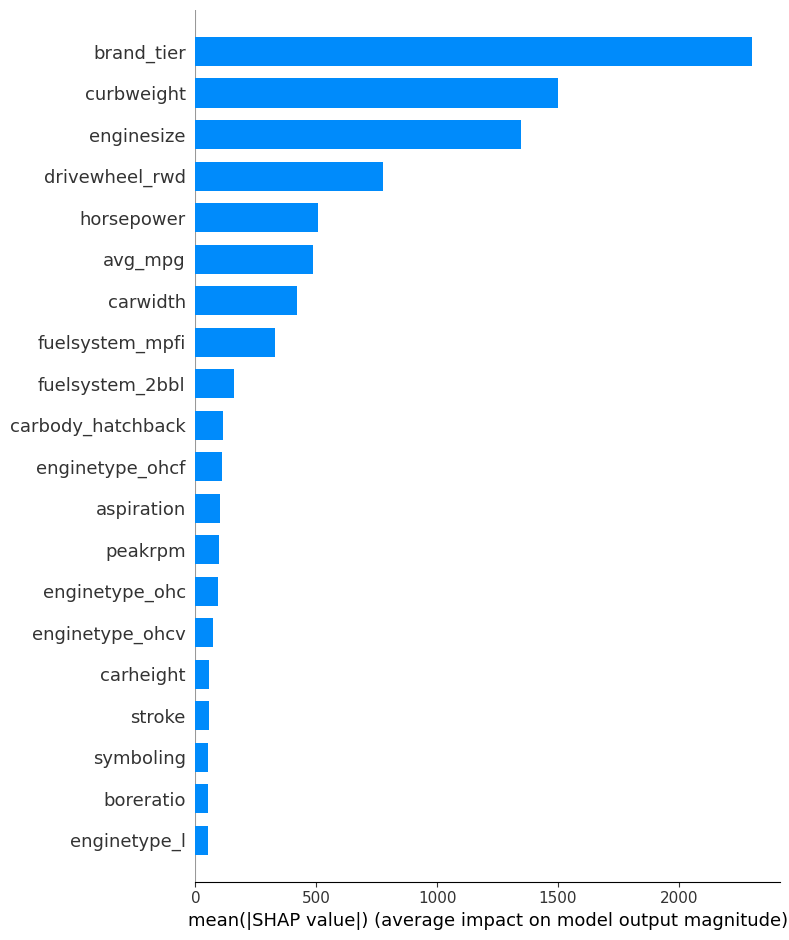

In [5]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("../visualizations/shap-bar.png", dpi=150, bbox_inches="tight")
plt.show()

**Summary plot (beeswarm)** - each dot is one test prediction. The x-axis shows the SHAP value (how much that feature pushed the price up or down), and the colour shows the feature's actual value (red = high, blue = low). This lets us see *direction* - e.g., does high engine size push price up or down?

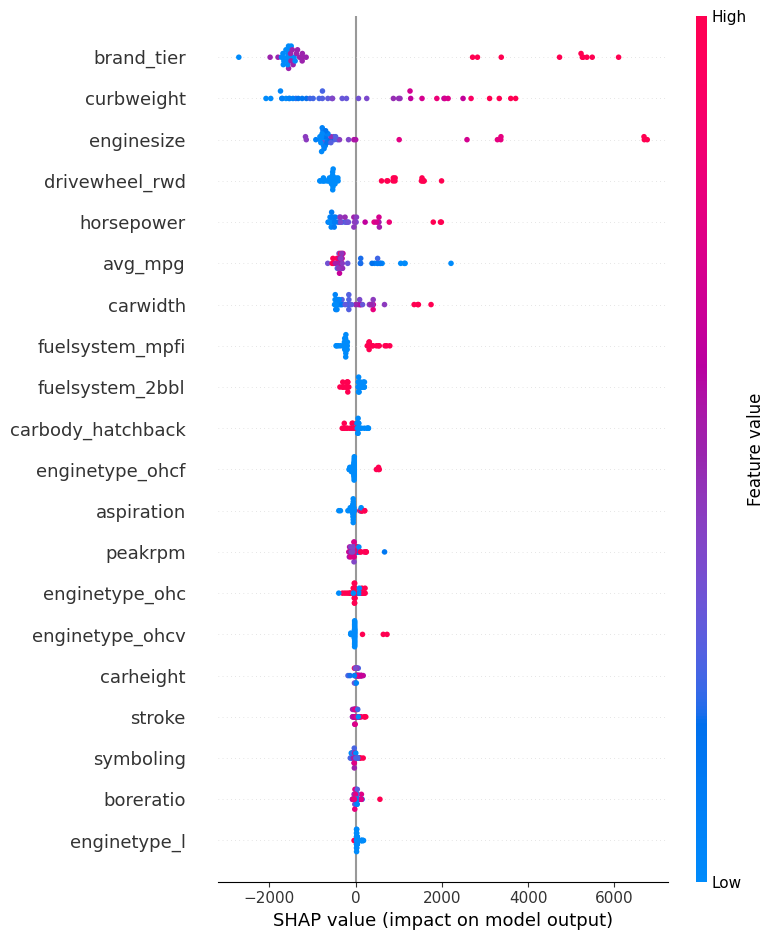

In [6]:
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("../visualizations/shap-summary.png", dpi=150, bbox_inches="tight")
plt.show()

### 3 - SHAP Local Explanations

Global plots show what matters *in general*. Waterfall plots show what happened for a *specific car* - how each feature pushed the prediction up or down from the average price.

We'll pick two contrasting test cases: the most expensive and cheapest predictions.

In [7]:
idx_expensive = y_pred.argmax()
idx_cheap = y_pred.argmin()

print(f"Most expensive prediction: ${y_pred[idx_expensive]:,.0f} (actual: ${y_test.iloc[idx_expensive]:,.0f})")
print(f"Cheapest prediction: ${y_pred[idx_cheap]:,.0f} (actual: ${y_test.iloc[idx_cheap]:,.0f})")

Most expensive prediction: $39,366 (actual: $40,960)
Cheapest prediction: $5,651 (actual: $5,151)


Waterfall: Most expensive prediction ($39,366)


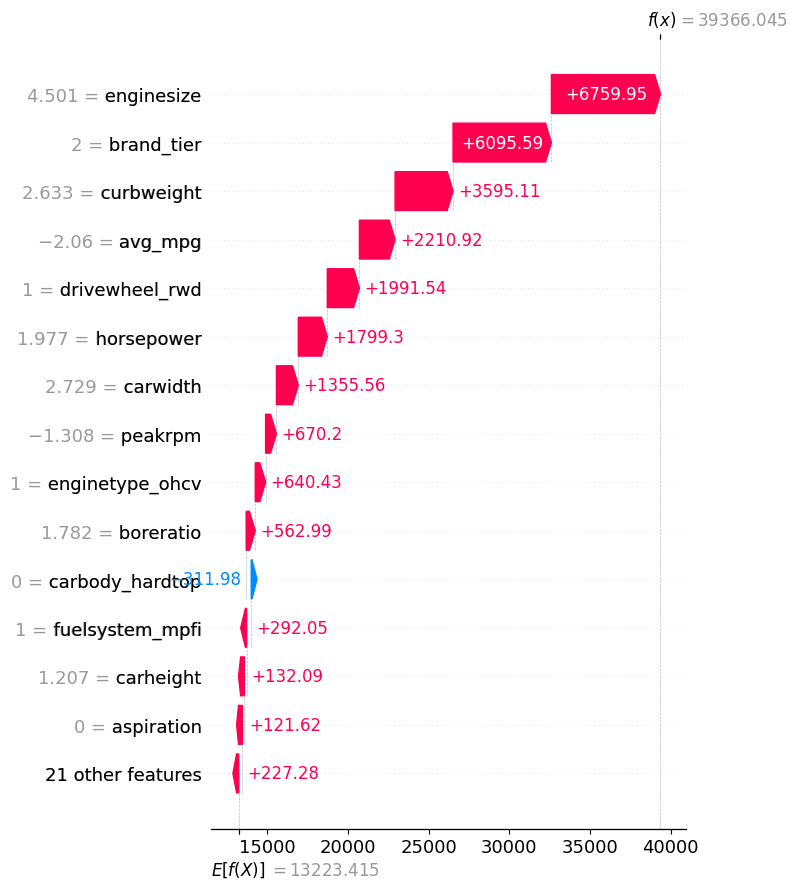

In [8]:
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(X_test), explainer.expected_value),
    data=X_test.values,
    feature_names=X_test.columns.tolist(),
)

print(f"Waterfall: Most expensive prediction (${y_pred[idx_expensive]:,.0f})")
shap.plots.waterfall(shap_explanation[idx_expensive], max_display=15, show=False)
plt.tight_layout()
plt.savefig("../visualizations/shap-waterfall-expensive.png", dpi=150, bbox_inches="tight")
plt.show()

Waterfall: Cheapest prediction ($5,651)


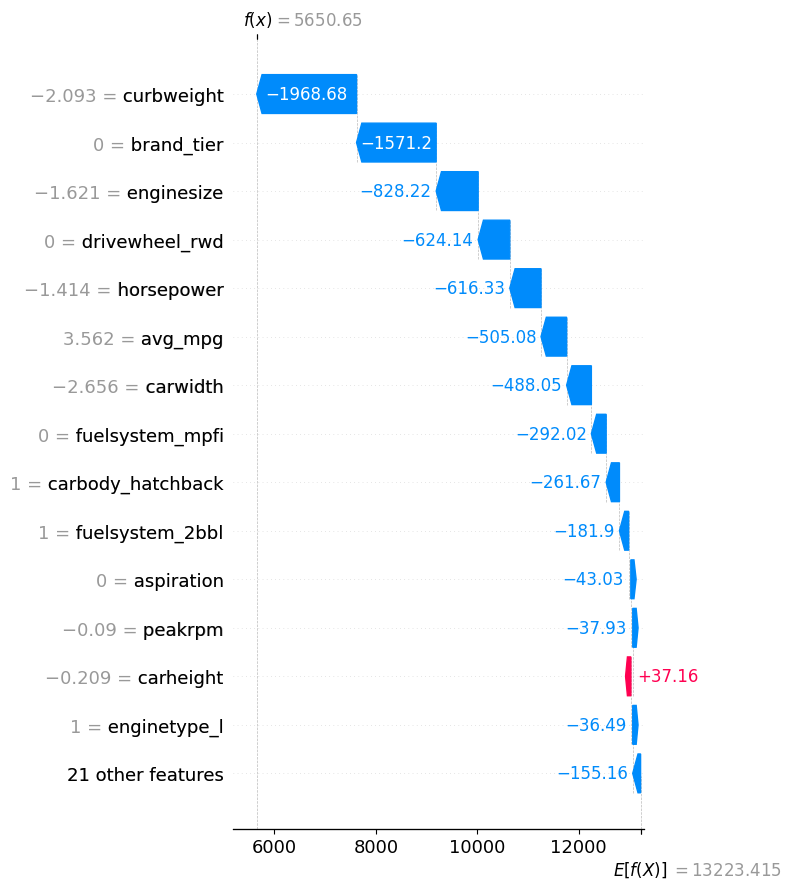

In [9]:
print(f"Waterfall: Cheapest prediction (${y_pred[idx_cheap]:,.0f})")
shap.plots.waterfall(shap_explanation[idx_cheap], max_display=15, show=False)
plt.tight_layout()
plt.savefig("../visualizations/shap-waterfall-cheap.png", dpi=150, bbox_inches="tight")
plt.show()

### 4 - LIME Local Explanations

**What is LIME?** LIME (Local Interpretable Model-agnostic Explanations) works differently from SHAP. It creates small variations of a single data point, sees how the model's predictions change, then fits a simple linear model to approximate what's happening locally. Think of it as zooming in on one neighbourhood of the data and asking "what matters here?"

Key difference from SHAP:
- **SHAP** is exact for tree models and considers all feature interactions
- **LIME** is an approximation that assumes features are roughly independent near the data point

We'll explain the same two cars (most expensive and cheapest) so we can compare.

In [10]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode="regression",
    random_state=42,
)

LIME: Most expensive prediction ($39,366)


/Users/annie/Projects/ml-car-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(


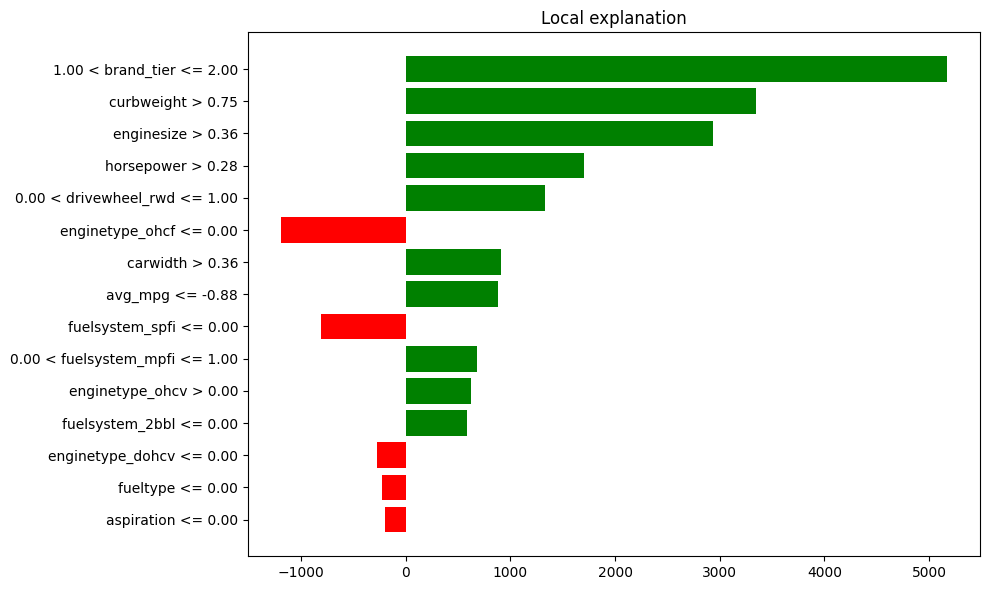

In [11]:
print(f"LIME: Most expensive prediction (${y_pred[idx_expensive]:,.0f})")
exp_expensive = lime_explainer.explain_instance(
    X_test.iloc[idx_expensive].values,
    model.predict,
    num_features=15,
)
fig = exp_expensive.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.savefig("../visualizations/lime-expensive.png", dpi=150, bbox_inches="tight")
plt.show()

LIME: Cheapest prediction ($5,651)


/Users/annie/Projects/ml-car-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(


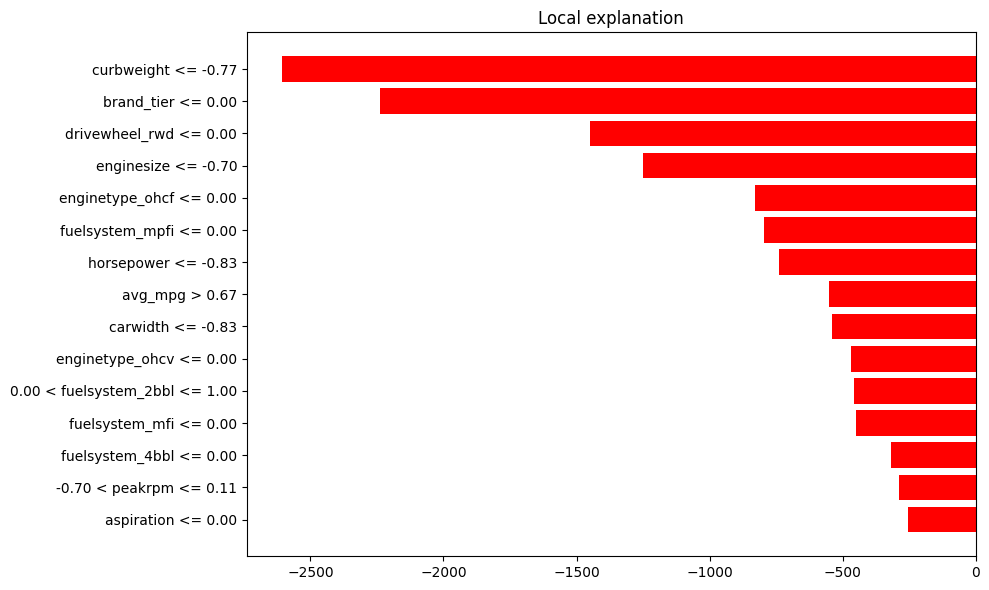

In [12]:
print(f"LIME: Cheapest prediction (${y_pred[idx_cheap]:,.0f})")
exp_cheap = lime_explainer.explain_instance(
    X_test.iloc[idx_cheap].values,
    model.predict,
    num_features=15,
)
fig = exp_cheap.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.savefig("../visualizations/lime-cheap.png", dpi=150, bbox_inches="tight")
plt.show()

### 5 - SHAP vs LIME Comparison

Let's compare what the two methods say about the same predictions. They won't always agree - that's expected and informative.

In [13]:
def get_top_features(shap_vals, lime_exp, feature_names, n=10):
    """Extract top features from both SHAP and LIME for comparison."""
    shap_importance = pd.Series(np.abs(shap_vals), index=feature_names).nlargest(n)

    # LIME labels features with ranges (e.g. "enginesize > 130.50")
    # Match them back to original feature names
    lime_raw = lime_exp.as_list()
    lime_dict = {}
    for label, weight in lime_raw:
        for fname in feature_names:
            if fname in label:
                lime_dict[fname] = lime_dict.get(fname, 0) + abs(weight)
                break
    lime_importance = pd.Series(lime_dict).nlargest(n)

    return shap_importance, lime_importance

for label, idx in [("Most Expensive", idx_expensive), ("Cheapest", idx_cheap)]:
    lime_exp = lime_explainer.explain_instance(
        X_test.iloc[idx].values, model.predict, num_features=35
    )
    shap_top, lime_top = get_top_features(
        shap_values[idx], lime_exp, X_test.columns.tolist()
    )

    print(f"\n{'='*55}")
    print(f"{label} Prediction - Top 10 Features")
    print(f"{'='*55}")
    comparison = pd.DataFrame({
        "SHAP Rank": range(1, 11),
        "SHAP Feature": shap_top.index.tolist(),
        "LIME Rank": range(1, 11),
        "LIME Feature": lime_top.index.tolist(),
    })
    print(comparison.to_string(index=False))

    overlap = set(shap_top.index) & set(lime_top.index)
    print(f"\nOverlap: {len(overlap)}/10 features agree - {sorted(overlap)}")


Most Expensive Prediction - Top 10 Features
 SHAP Rank    SHAP Feature  LIME Rank    LIME Feature
         1      enginesize          1      brand_tier
         2      brand_tier          2      curbweight
         3      curbweight          3      enginesize
         4         avg_mpg          4  enginetype_ohc
         5  drivewheel_rwd          5      horsepower
         6      horsepower          6  drivewheel_rwd
         7        carwidth          7         avg_mpg
         8         peakrpm          8 fuelsystem_spfi
         9 enginetype_ohcv          9        carwidth
        10       boreratio         10 fuelsystem_mpfi

Overlap: 7/10 features agree - ['avg_mpg', 'brand_tier', 'carwidth', 'curbweight', 'drivewheel_rwd', 'enginesize', 'horsepower']


/Users/annie/Projects/ml-car-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(
/Users/annie/Projects/ml-car-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(



Cheapest Prediction - Top 10 Features
 SHAP Rank      SHAP Feature  LIME Rank    LIME Feature
         1        curbweight          1      curbweight
         2        brand_tier          2      brand_tier
         3        enginesize          3  drivewheel_rwd
         4    drivewheel_rwd          4      enginesize
         5        horsepower          5  enginetype_ohc
         6           avg_mpg          6      horsepower
         7          carwidth          7        carwidth
         8   fuelsystem_mpfi          8 carbody_hardtop
         9 carbody_hatchback          9 fuelsystem_2bbl
        10   fuelsystem_2bbl         10 fuelsystem_spfi

Overlap: 7/10 features agree - ['brand_tier', 'carwidth', 'curbweight', 'drivewheel_rwd', 'enginesize', 'fuelsystem_2bbl', 'horsepower']


### 6 - Business Interpretation

*Fill in observations after running the notebook. Key questions to answer:*

**Feature importance:**
- Which features most strongly influence car price predictions?
- Do the engineered features (`avg_mpg`, `hp_per_weight`, `brand_tier`) appear in the top features? This validates our feature engineering effort.

**SHAP vs LIME:**
- Where do they agree? Agreement builds confidence in those features genuinely mattering.
- Where do they disagree? Disagreement often happens with correlated features (e.g., `enginesize` and `curbweight` both capture "how big is this car"). SHAP handles correlations better because TreeExplainer accounts for feature interactions; LIME's local linear approximation can split credit unpredictably between correlated features.

**When to use which:**
- **SHAP** is better for this project because we have a tree model and want exact, consistent explanations. It's the go-to for regulatory or stakeholder reporting where you need to defend your model's reasoning.
- **LIME** is useful when you want a quick, model-agnostic sanity check, or when working with models that SHAP doesn't support natively (e.g., deep learning). It's also more intuitive to explain to non-technical audiences because it answers a simple question: "what would change the prediction?"

**Trust:**
- If both methods point to the same features driving a prediction, we can be more confident the model is learning real patterns rather than noise.
- Features that make business sense (engine size, curb weight, brand tier) appearing as top predictors is a good sign - the model aligns with domain knowledge about what makes cars expensive.